# Conditional Diffusion for Turbine Operation <sup>🔥 gas turbine</sup>

Day 3 trained an *unconditional* diffusion model on pump data — it generated healthy operation, but you could not ask it for anything specific. Today we add the missing control: **conditioning**, and the trick that makes conditioning actually bite, **classifier-free guidance**. Same 1D U-Net, same noise schedule, two small additions.

The data is real: **36,733 hours** of a gas turbine in north-western Türkiye, 2011–2015, from the UCI machine-learning repository ([CC BY 4.0](https://archive.ics.uci.edu/dataset/551/gas+turbine+co+and+nox+emission+data+set)). Eleven tags, hourly — ambient conditions, compressor and turbine pressures and temperatures, electrical load, and the two stack emissions that sit on an environmental permit.

The task: **generate a plausible week of turbine operation, on demand, for a given ambient condition.**

Why that is worth doing on a real unit:

| Use | What you get |
|---|---|
| Emissions what-if | "what would CO and NOx look like across a hot week at high load?" — permit headroom without waiting for summer |
| Augmentation | synthetic operating weeks to train an emissions surrogate when measured stack data is scarce |
| Gap filling | this dataset is genuinely missing ~16% of its hours; the same model inpaints them |

And the part that makes it a *lab* rather than a demo: we do not judge the samples by eye. We score them against **measured physics** — correlations the machine must obey, a temperature ceiling it cannot exceed, an emissions floor it cannot go below. You get a pass/fail number you could defend to a plant manager.

> **Runtime.** About 10–15 minutes on a Colab T4. Set *Runtime → Change runtime type → T4 GPU*.

## Setup

In [1]:
#@title imports
import math, io, zipfile, urllib.request, copy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

np.seterr(all="ignore")          # Apple/BLAS builds raise spurious matmul FPE flags
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
torch.manual_seed(0); np.random.seed(0)
print("device:", device, "| torch", torch.__version__)

device: mps | torch 2.8.0


## The machine

A single gas turbine, logged hourly. Every tag is one a utilities or process engineer already trends on a DCS.

| Tag | Units | What it is |
|---|---|---|
| `AT`, `AP`, `AH` | °C, mbar, % | ambient temperature, pressure, relative humidity |
| `AFDP` | mbar | air filter differential pressure |
| `GTEP` | mbar | turbine exhaust pressure |
| `TIT` | °C | turbine inlet temperature |
| `TAT` | °C | turbine after (exhaust) temperature |
| `TEY` | MWh | turbine energy yield — the load |
| `CDP` | mbar | compressor discharge pressure |
| `CO` | mg/m³ | carbon monoxide in the stack |
| `NOX` | mg/m³ | nitrogen oxides in the stack |

Ambient conditions are the *inputs* the operator cannot control; load is what they dispatch; CO and NOx are what the regulator reads. That causal ordering is what makes conditioning natural here — you condition on the weather, not on the emissions.

In [2]:
#@title download the UCI gas turbine dataset
URL  = "https://archive.ics.uci.edu/static/public/551/gas+turbine+co+and+nox+emission+data+set.zip"
root = Path("gt"); root.mkdir(exist_ok=True)
zp   = root / "gt.zip"
if not zp.exists():
    urllib.request.urlretrieve(URL, zp)
with zipfile.ZipFile(zp) as z:
    z.extractall(root)

TAGS = ["AT","AP","AH","AFDP","GTEP","TIT","TAT","TEY","CDP","CO","NOX"]
df = pd.concat([pd.read_csv(root / f"gt_{y}.csv").assign(year=y) for y in range(2011, 2016)],
               ignore_index=True)
print(f"{len(df):,} hourly records | {df.year.min()}-{df.year.max()} | {len(TAGS)} tags")
print(df.groupby("year").size().rename("rows").to_frame().T.to_string())
assert df[TAGS].isna().sum().sum() == 0, "unexpected NaNs"

36,733 hourly records | 2011-2015 | 11 tags
year  2011  2012  2013  2014  2015
rows  7411  7628  7152  7158  7384


## Know your data

Three questions before any modelling. Each one changes the lab design.

AT      0.993
AP      0.997
AH      0.958
AFDP    0.921
GTEP    0.856
TIT     0.826
TAT     0.841
TEY     0.853
CDP     0.857
CO      0.655
NOX     0.896

weakest channel: CO at 0.655


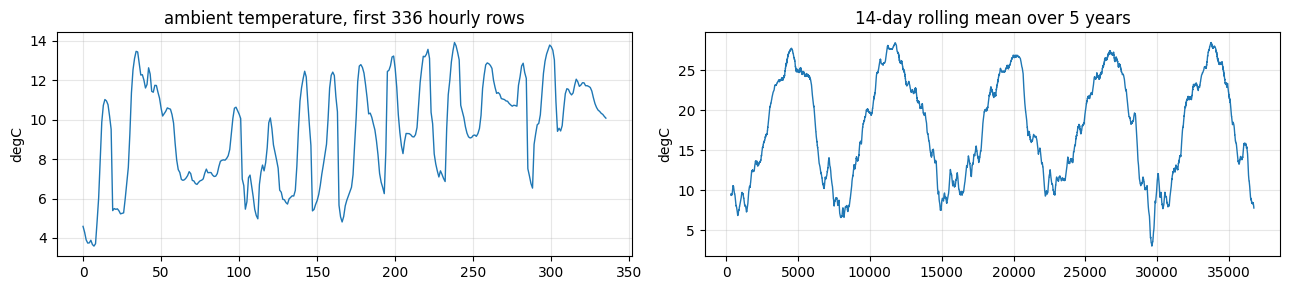

In [3]:
#@title 1. is this a real time series, or has it been shuffled?
acf = pd.Series({c: df[c].autocorr(1) for c in TAGS}, name="lag-1 autocorr")
print(acf.round(3).to_string())
print(f"\nweakest channel: {acf.idxmin()} at {acf.min():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 3))
ax[0].plot(df.AT.values[:24*14], lw=1); ax[0].set_title("ambient temperature, first 336 hourly rows"); ax[0].grid(alpha=0.3)
ax[1].plot(df.AT.rolling(24*14).mean().values, lw=1); ax[1].set_title("14-day rolling mean over 5 years"); ax[1].grid(alpha=0.3)
for a in ax: a.set_ylabel("degC")
plt.tight_layout(); plt.show()

Every channel is strongly autocorrelated at lag 1, the first fortnight shows a clean diurnal cycle, and the five-year rolling mean traces summer peaks. This is a genuine, chronologically-ordered series — windowed generation is meaningful.

**But there is no timestamp column.** Count the rows against the calendar and 13–18% of every year's hours are simply absent, with no way to tell where the gaps fall. So, exactly as on Day 3, our windows are **index-contiguous, not time-contiguous** — a "week" is 168 consecutive *rows*, which is on average a little more than a week of wall clock. We never window across a year boundary, which is the one gap we *can* locate.

In [4]:
#@title 2. how much of the calendar is missing?
rows = []
for y in range(2011, 2016):
    hours = 8784 if y % 4 == 0 else 8760
    n = int((df.year == y).sum())
    rows.append({"rows": n, "calendar hours": hours, "missing %": 100 * (1 - n / hours)})
print(pd.DataFrame(rows, index=range(2011, 2016)).round(1).to_string())

      rows  calendar hours  missing %
2011  7411            8760       15.4
2012  7628            8784       13.2
2013  7152            8760       18.4
2014  7158            8760       18.3
2015  7384            8760       15.7


          min      max  most common value  share of hours %
AT      -6.23    37.10              18.52              0.02
AP     985.85  1036.60            1012.10              0.81
AH      24.08   100.20             100.14              0.13
AFDP     2.09     7.61               4.01              0.02
GTEP    17.70    40.72              24.31              0.05
TIT   1000.80  1100.90            1100.00              7.45
TAT    511.04   550.61             550.01              1.79
TEY    100.02   179.50             133.78              0.50
CDP      9.85    15.16              11.89              0.15
CO       0.00    44.10               0.11              0.06
NOX     25.90   119.91              60.38              0.28

TIT within 1 degC of its 1100 ceiling : 23.95% of hours
TAT within 1 degC of its 550 setpoint : 67.42% of hours
CO floor                              : 0.000 mg/m3  (never negative)


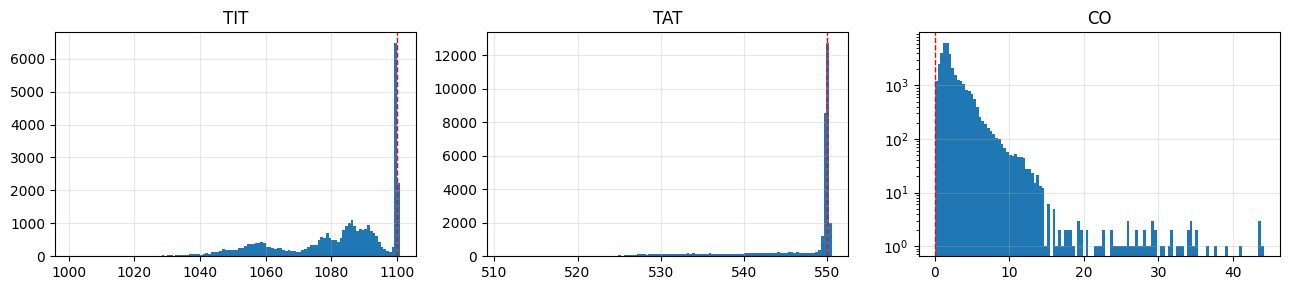

In [5]:
#@title 3. where are the hard physical limits?
lim = pd.DataFrame({
    "min":  [df[c].min()  for c in TAGS],
    "max":  [df[c].max()  for c in TAGS],
    "most common value": [df[c].value_counts().index[0] for c in TAGS],
    "share of hours %":  [100 * df[c].value_counts(normalize=True).iloc[0] for c in TAGS],
}, index=TAGS)
print(lim.round(2).to_string())

print(f"\nTIT within 1 degC of its 1100 ceiling : {100*(df.TIT >= 1099).mean():5.2f}% of hours")
print(f"TAT within 1 degC of its 550 setpoint : {100*(df.TAT >= 549).mean():5.2f}% of hours")
print(f"CO floor                              : {df.CO.min():.3f} mg/m3  (never negative)")

fig, ax = plt.subplots(1, 3, figsize=(13, 3))
for a, c in zip(ax, ["TIT", "TAT", "CO"]):
    a.hist(df[c], bins=120); a.set_title(c); a.grid(alpha=0.3)
ax[0].axvline(1100, color="r", ls="--", lw=1); ax[1].axvline(550, color="r", ls="--", lw=1)
ax[2].axvline(0, color="r", ls="--", lw=1); ax[2].set_yscale("log")
plt.tight_layout(); plt.show()

This is the cell that decides whether the lab has a point.

- **`TIT` is control-clipped.** A turbine inlet temperature limiter holds it at 1100 °C; **24% of all hours sit within 1 °C of that ceiling**, with a hard pile-up of mass against it.
- **`TAT` is held at a setpoint.** Two-thirds of hours sit within 1 °C of 550 °C — the exhaust temperature controller doing its job.
- **`CO` has a floor at zero.** It is a concentration; negative values are not "unlikely", they are meaningless.

A symmetric, unbounded model — a Gaussian, say — will smear straight through all three. Keep this in mind: it is the whole basis of the scorecard later.

## Windows, split, and the conditioning label

- **Window = 168 rows**, our "week".
- **Split by year, the UCI convention**: train on 2011–2013, hold out 2014–2015. Splitting by year rather than at random is the only honest option when windows overlap.
- **Standardise on training years only.**
- **Conditioning label = ambient tercile** of the window's mean `AT` — cold / mild / hot — with the tercile edges taken from the *training* windows. We condition on weather because it is the one thing the operator does not choose.

Training stride is 3 rather than 1. Stride-1 windows share 167 of 168 samples; the extra copies cost time and teach the model nothing. Even at stride 3 the honest independent-sample count is `rows / 168` ≈ **132 weeks of training data**, not the window count. Small-data regime again — say it out loud.

In [6]:
#@title build windows and labels
WINDOW    = 168      # hours in our "week"
STRIDE_TR = 3
STRIDE_TE = 6
N_CLASSES = 3        # cold / mild / hot
CLASS_NAMES = ["cold", "mild", "hot"]

def windows(arr, length, stride):
    n = (len(arr) - length) // stride + 1
    return np.stack([arr[i*stride:i*stride+length] for i in range(n)]) if n > 0 else np.zeros((0, length, arr.shape[1]))

train_df, test_df = df[df.year <= 2013], df[df.year >= 2014]
mu, sd = train_df[TAGS].values.mean(0), train_df[TAGS].values.std(0)

def build(d, stride):
    out = []
    for y in sorted(d.year.unique()):                      # never window across a year boundary
        z = (d[d.year == y][TAGS].values.astype(np.float64) - mu) / sd
        w = windows(z, WINDOW, stride)
        if len(w): out.append(w)
    return np.concatenate(out).astype(np.float32)

x_train, x_test = build(train_df, STRIDE_TR), build(test_df, STRIDE_TE)
AT = TAGS.index("AT")
edges = np.quantile(x_train[:, :, AT].mean(1), [1/3, 2/3])          # train windows only
y_train = np.digitize(x_train[:, :, AT].mean(1), edges)
y_test  = np.digitize(x_test[:, :, AT].mean(1),  edges)

print(f"train {x_train.shape} | test {x_test.shape}")
print(f"label balance  train {np.bincount(y_train)}  test {np.bincount(y_test)}")
print(f"independent weeks: train {len(train_df)//WINDOW} | test {len(test_df)//WINDOW}")
at_c = lambda k, X, Y: (X[Y == k][:, :, AT].mean() * sd[AT] + mu[AT])
print("mean ambient per class (degC):  " + "  ".join(f"{n} {at_c(i, x_train, y_train):5.1f}" for i, n in enumerate(CLASS_NAMES)))

train (7231, 168, 11) | test (2369, 168, 11)
label balance  train [2410 2410 2411]  test [828 781 760]
independent weeks: train 132 | test 86
mean ambient per class (degC):  cold  10.2  mild  18.1  hot  25.4


In [7]:
#@title the regime break you must know about
per_year = df.groupby("year")[["NOX","CO","TEY","TIT"]].mean()
print(per_year.round(2).to_string())
shift = ((test_df[TAGS].mean() - train_df[TAGS].mean()) / train_df[TAGS].std()).sort_values()
print("\nheld-out minus training mean, in training sigma:")
print(shift.round(2).to_string())

        NOX    CO     TEY      TIT
year                              
2011  67.58  1.57  135.75  1084.73
2012  68.79  2.36  132.68  1082.89
2013  70.01  2.72  132.17  1081.57
2014  60.07  2.08  132.91  1078.84
2015  59.89  3.13  133.99  1078.97

held-out minus training mean, in training sigma:
NOX    -0.80
AFDP   -0.35
AH     -0.31
TIT    -0.25
TEY    -0.00
AT      0.00
CDP     0.00
AP      0.10
GTEP    0.15
CO      0.17
TAT     0.21


`NOX` averages ~70 mg/m³ through 2013 and ~60 from 2014 — a **0.8σ step down**, while no other tag moves even 0.35σ. That is not noise; something changed on the unit between 2013 and 2014 (a NOx control retrofit or a stack analyser recalibration — the dataset does not say).

This matters for what follows. Our model is trained on 2011–2013, so it will generate **pre-retrofit NOx**. When the held-out years disagree on that one channel, the model is not broken — it is faithfully reproducing the plant it was shown. Any historian pull spanning a plant modification has this property, and noticing it is the job.

## Conditioning, and why guidance is needed

Two additions to the Day 3 network.

**1. A label embedding.** `nn.Embedding(N_CLASSES + 1, t_dim)`, added to the timestep embedding. That extra `+1` row is a **null token** meaning "no condition given" — it is what makes guidance possible.

**2. Label dropout during training.** With probability 10% we replace the real label with the null token. The single network therefore learns the conditional score *and* the unconditional score at once.

At sampling time we run the model twice and extrapolate away from the unconditional prediction:

`eps = eps(x, t, null) + w · [ eps(x, t, class) − eps(x, t, null) ]`

That is **classifier-free guidance** (Ho & Salimans, 2022). At `w = 1` you get ordinary conditional sampling. Above 1 you exaggerate whatever makes this class different from the average week — sharper conditioning, at the cost of diversity. The trick avoids needing a separately-trained classifier, which is why it replaced classifier guidance everywhere, Stable Diffusion included.

In [8]:
#@title conditional 1D UNet
class SinusoidalTime(nn.Module):
    def __init__(self, dim): super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freq = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
        ang  = t.float()[:, None] * freq[None]
        return torch.cat([ang.sin(), ang.cos()], dim=1)

class ResBlock(nn.Module):
    def __init__(self, c_in, c_out, t_dim, groups=8):
        super().__init__()
        self.norm1 = nn.GroupNorm(min(groups, c_in), c_in)
        self.conv1 = nn.Conv1d(c_in, c_out, 3, padding=1)
        self.emb   = nn.Linear(t_dim, c_out * 2)
        self.norm2 = nn.GroupNorm(min(groups, c_out), c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, 3, padding=1)
        self.skip  = nn.Conv1d(c_in, c_out, 1) if c_in != c_out else nn.Identity()
        nn.init.zeros_(self.conv2.weight); nn.init.zeros_(self.conv2.bias)
    def forward(self, x, emb):
        h = self.conv1(F.silu(self.norm1(x)))
        scale, shift = self.emb(F.silu(emb))[:, :, None].chunk(2, dim=1)
        return self.conv2(F.silu(self.norm2(h) * (1 + scale) + shift)) + self.skip(x)

class CondUNet1D(nn.Module):
    def __init__(self, channels, n_classes, base=64, mults=(1, 2, 2), t_dim=128):
        super().__init__()
        self.time  = nn.Sequential(SinusoidalTime(base), nn.Linear(base, t_dim), nn.SiLU(), nn.Linear(t_dim, t_dim))
        self.label = nn.Embedding(n_classes + 1, t_dim)          # last row = null token
        self.stem  = nn.Conv1d(channels, base, 3, padding=1)
        widths, prev = [base * m for m in mults], base
        self.down, self.pool = nn.ModuleList(), nn.ModuleList()
        for i, w in enumerate(widths):
            self.down.append(nn.ModuleList([ResBlock(prev, w, t_dim), ResBlock(w, w, t_dim)]))
            self.pool.append(nn.Conv1d(w, w, 4, stride=2, padding=1) if i < len(widths)-1 else nn.Identity())
            prev = w
        self.mid1, self.mid2 = ResBlock(prev, prev, t_dim), ResBlock(prev, prev, t_dim)
        self.up, self.upsample = nn.ModuleList(), nn.ModuleList()
        for i, w in reversed(list(enumerate(widths))):
            self.upsample.append(nn.ConvTranspose1d(prev, prev, 4, stride=2, padding=1) if i < len(widths)-1 else nn.Identity())
            self.up.append(nn.ModuleList([ResBlock(prev + w, w, t_dim), ResBlock(w, w, t_dim)]))
            prev = w
        self.out_norm = nn.GroupNorm(8, prev)
        self.out      = nn.Conv1d(prev, channels, 3, padding=1)
        nn.init.zeros_(self.out.weight); nn.init.zeros_(self.out.bias)
    def forward(self, x, t, y):
        emb = self.time(t) + self.label(y)                       # conditioning enters here
        h, skips = self.stem(x), []
        for (b1, b2), pool in zip(self.down, self.pool):
            h = b2(b1(h, emb), emb); skips.append(h); h = pool(h)
        h = self.mid2(self.mid1(h, emb), emb)
        for (b1, b2), ups in zip(self.up, self.upsample):
            h = ups(h); h = b2(b1(torch.cat([h, skips.pop()], dim=1), emb), emb)
        return self.out(F.silu(self.out_norm(h)))

CHANNELS = len(TAGS)
model = CondUNet1D(CHANNELS, N_CLASSES).to(device)
print(f"params {sum(p.numel() for p in model.parameters())/1e6:.2f}M | {WINDOW} -> {WINDOW//2} -> {WINDOW//4}")

params 1.92M | 168 -> 84 -> 42


In [9]:
#@title noise schedule (the Day 3 schedule, unchanged)
T_STEPS, BETA_MAX = 400, 0.05

def cosine_betas(T, beta_max):
    f    = lambda u: torch.cos((u + 0.008) / 1.008 * math.pi / 2) ** 2
    u    = torch.linspace(0, 1, T + 1)
    abar = f(u) / f(torch.tensor(0.0))
    return (1 - abar[1:] / abar[:-1]).clamp(1e-8, beta_max)

betas     = cosine_betas(T_STEPS, BETA_MAX).to(device)
alphas    = 1 - betas
abar      = torch.cumprod(alphas, 0)
abar_prev = torch.cat([torch.ones(1, device=device), abar[:-1]])
sqrt_abar, sqrt_1mab = abar.sqrt(), (1 - abar).sqrt()
post_var  = (betas * (1 - abar_prev) / (1 - abar)).clamp(min=1e-20)
coef_x0   = abar_prev.sqrt() * betas / (1 - abar)
coef_xt   = alphas.sqrt() * (1 - abar_prev) / (1 - abar)

def q_sample(x0, t, noise):
    return sqrt_abar[t][:, None, None] * x0 + sqrt_1mab[t][:, None, None] * noise

print(f"T={T_STEPS} | beta {betas[0]:.2e} -> {betas[-1]:.3f} | sqrt(abar_T)={sqrt_abar[-1]:.4f}")

T=400 | beta 1.12e-04 -> 0.050 | sqrt(abar_T)=0.0557


## Training

In [10]:
#@title training config
EPOCHS      = 20
BATCH_SIZE  = 128
MAX_LR      = 3e-4
EMA_DECAY   = 0.995
LABEL_DROP  = 0.10          # probability of swapping the true label for the null token

xt = torch.tensor(x_train).permute(0, 2, 1)
yt = torch.tensor(y_train)
loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(xt, yt),
                                     batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
print(f"{len(xt):,} windows | {len(loader)} batches/epoch | {EPOCHS*len(loader)} steps")

7,231 windows | 56 batches/epoch | 1120 steps


training:   0%|          | 0/20 [00:00<?, ?it/s]

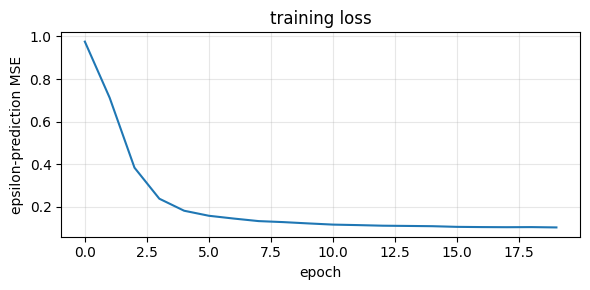

training complete ✓


In [11]:
#@title train
ema = copy.deepcopy(model).eval().requires_grad_(False)
opt = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=MAX_LR, total_steps=EPOCHS*len(loader), pct_start=0.1)

hist = []
pbar = tqdm(range(EPOCHS), desc="training")
for epoch in pbar:
    model.train(); running, seen = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        drop = torch.rand(len(yb), device=device) < LABEL_DROP
        yb = torch.where(drop, torch.full_like(yb, N_CLASSES), yb)      # null token
        t = torch.randint(0, T_STEPS, (len(xb),), device=device)
        e = torch.randn_like(xb)
        loss = F.mse_loss(model(q_sample(xb, t, e), t, yb), e)
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
        with torch.no_grad():
            for p, q in zip(ema.parameters(), model.parameters()):
                p.mul_(EMA_DECAY).add_(q, alpha=1-EMA_DECAY)
        running += loss.item()*len(xb); seen += len(xb)
    hist.append(running/seen); pbar.set_postfix(loss=f"{hist[-1]:.4f}")

plt.figure(figsize=(6,3)); plt.plot(hist, lw=1.5)
plt.xlabel("epoch"); plt.ylabel("epsilon-prediction MSE"); plt.grid(alpha=0.3)
plt.title("training loss"); plt.tight_layout(); plt.show()
print("training complete ✓")

## Sampling with guidance

Same x₀-parameterised reverse step as Day 3, with the guidance combination inserted. Note the cost: at `w ≠ 1` every step needs **two** forward passes, so guided sampling is twice the price.

In [12]:
#@title guided sampler
@torch.no_grad()
def sample(n, cls, guidance=1.0, clip=5.0, seed=0):
    g = torch.Generator().manual_seed(seed)
    x = torch.randn(n, CHANNELS, WINDOW, generator=g).to(device)
    y    = torch.full((n,), cls,       device=device, dtype=torch.long)
    null = torch.full((n,), N_CLASSES, device=device, dtype=torch.long)
    for i in reversed(range(T_STEPS)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        eps = ema(x, t, y)
        if guidance != 1.0:
            eps_u = ema(x, t, null)
            eps = eps_u + guidance * (eps - eps_u)             # classifier-free guidance
        x0 = ((x - sqrt_1mab[i]*eps) / sqrt_abar[i]).clamp(-clip, clip)
        mean = coef_x0[i]*x0 + coef_xt[i]*x
        x = mean + post_var[i].sqrt()*torch.randn(x.shape, generator=g).to(device) if i > 0 else mean
    return x

def to_physical(z):                     # (N,C,L) standardised -> (N,L,C) engineering units
    return z.transpose(0, 2, 1) * sd + mu

N_PER_CLASS = 48
bank = {}
for w in [1.0, 2.0]:
    bank[w] = [sample(N_PER_CLASS, c, guidance=w, seed=10+c).cpu().numpy() for c in range(N_CLASSES)]
    print(f"sampled guidance w={w}")

sampled guidance w=1.0


sampled guidance w=2.0


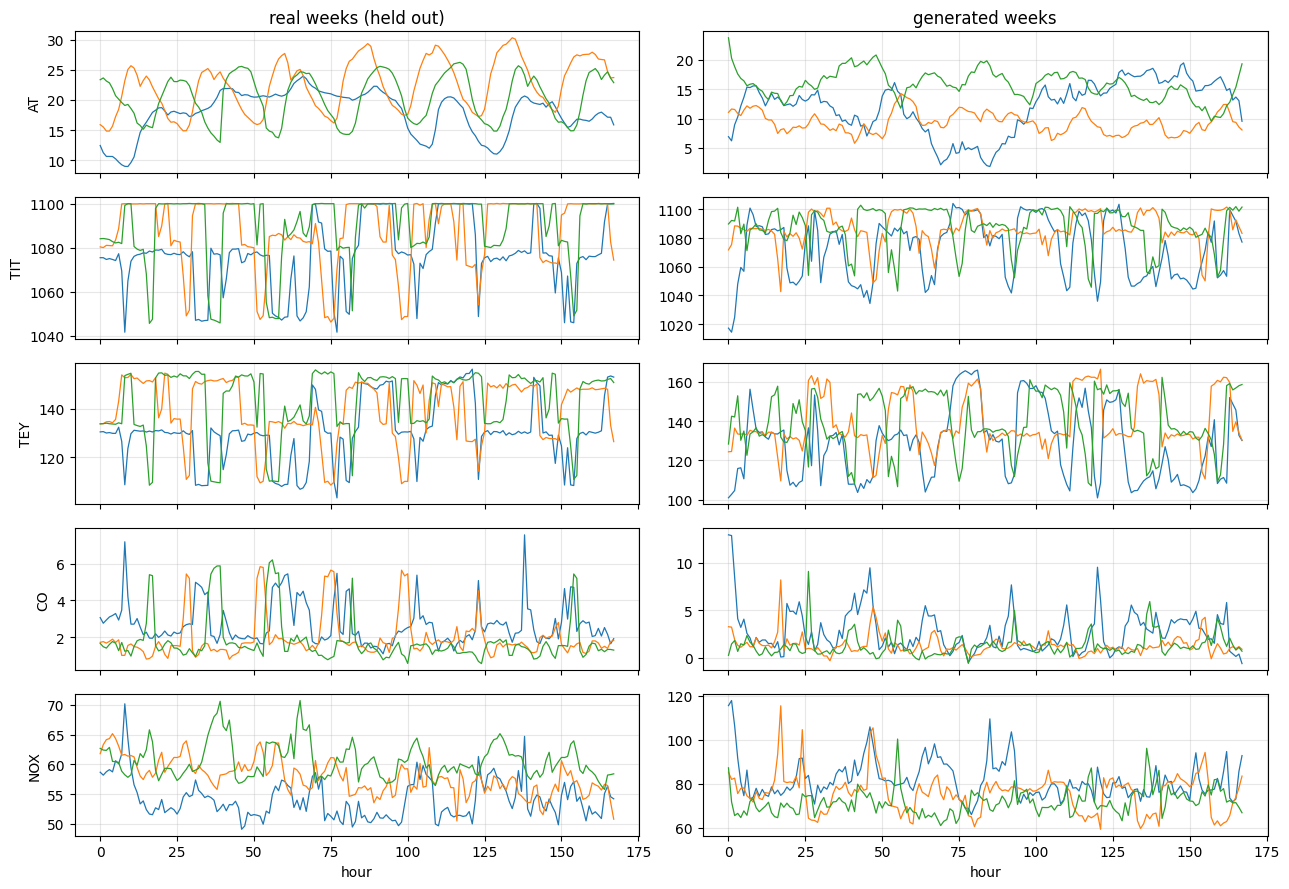

In [13]:
#@title what does a generated week look like?
gen = to_physical(np.concatenate(bank[1.0]))
real = to_physical(x_test[np.random.RandomState(0).choice(len(x_test), len(gen), replace=False)].transpose(0,2,1))
show = ["AT","TIT","TEY","CO","NOX"]
fig, axes = plt.subplots(len(show), 2, figsize=(13, 9), sharex=True)
for r, tag in enumerate(show):
    k = TAGS.index(tag)
    for j in range(3): axes[r,0].plot(real[j,:,k], lw=0.9)
    for j in range(3): axes[r,1].plot(gen[j,:,k],  lw=0.9)
    axes[r,0].set_ylabel(tag); axes[r,0].grid(alpha=0.3); axes[r,1].grid(alpha=0.3)
axes[0,0].set_title("real weeks (held out)"); axes[0,1].set_title("generated weeks")
axes[-1,0].set_xlabel("hour"); axes[-1,1].set_xlabel("hour")
plt.tight_layout(); plt.show()

## The physics scorecard

Here is the part that separates this from an image lab. We do not ask whether the samples *look* right — we ask whether they obey the machine.

Six physical checks, every reference band measured from the real data (the table also reports lag-1 autocorrelation, which is a dynamics check rather than a physics one):

| Check | Why it must hold |
|---|---|
| `corr(TEY, CDP)` | load and compressor discharge pressure are rigidly coupled on a single-shaft machine |
| `corr(GTEP, CDP)` | exhaust and discharge pressure track together |
| `corr(CO, TIT)` | CO burns out as firing temperature rises — the correlation is negative |
| `CO < 0` | a concentration cannot be negative |
| `TIT > 1101 °C` | the inlet temperature limiter forbids it |
| `TAT` at setpoint | two-thirds of real hours sit within 1 °C of 550 °C; a model that loses this has lost the controller |
| `AT` lag-1 autocorrelation | ambient temperature is smooth hour to hour; a sampler that draws each hour independently cannot fake it |

In [14]:
#@title scorecard
def scorecard(P):
    """P: (N, L, C) in engineering units."""
    g = lambda c: P[:, :, TAGS.index(c)]
    return {
        "corr(TEY,CDP)":     np.corrcoef(g("TEY").ravel(), g("CDP").ravel())[0,1],
        "corr(GTEP,CDP)":    np.corrcoef(g("GTEP").ravel(), g("CDP").ravel())[0,1],
        "corr(CO,TIT)":      np.corrcoef(g("CO").ravel(),  g("TIT").ravel())[0,1],
        "CO<0 %":            100*(g("CO") < 0).mean(),
        "TIT>1101 %":        100*(g("TIT") > 1101).mean(),
        "TAT@setpoint %":    100*((g("TAT") >= 549) & (g("TAT") <= 551)).mean(),
        "AT lag-1 acf":      float(np.mean([np.corrcoef(w[:-1], w[1:])[0,1] for w in g("AT")])),
    }

# a strong Gaussian baseline: per-hour multivariate normal fitted on the training windows.
# By construction it reproduces every cross-channel correlation almost exactly.
flat = x_train.reshape(-1, CHANNELS)
gauss = np.random.RandomState(0).multivariate_normal(flat.mean(0), np.cov(flat.T),
                                                    size=len(gen)*WINDOW).reshape(len(gen), WINDOW, CHANNELS)
gauss = gauss * sd + mu

report = pd.DataFrame({
    "REAL train":       scorecard(to_physical(x_train[np.random.RandomState(1).choice(len(x_train), len(gen), replace=False)].transpose(0,2,1))),
    "REAL held-out":    scorecard(real),
    "diffusion w=1":    scorecard(to_physical(np.concatenate(bank[1.0]))),
    "diffusion w=2":    scorecard(to_physical(np.concatenate(bank[2.0]))),
    "Gaussian":         scorecard(gauss),
}).T
print(report.round(3).to_string())

               corr(TEY,CDP)  corr(GTEP,CDP)  corr(CO,TIT)  CO<0 %  TIT>1101 %  TAT@setpoint %  AT lag-1 acf
REAL train             0.988           0.994        -0.723   0.000       0.000          69.916         0.964
REAL held-out          0.987           0.956        -0.658   0.000       0.000          67.167         0.959
diffusion w=1          0.985           0.990        -0.796   1.600       5.795          55.820         0.929
diffusion w=2          0.984           0.990        -0.800   2.695       6.932          53.398         0.929
Gaussian               0.989           0.994        -0.724  16.460      14.513           8.738         0.002


Read the Gaussian row first, then read the diffusion rows honestly.

**The Gaussian passes every correlation test and is still nonsense.** It reproduces `corr(TEY,CDP)` at 0.989 against the real 0.988, and `corr(GTEP,CDP)` at 0.994 against 0.994 — better agreement than the diffusion model achieves. On any second-moment check it wins. And yet **16.5% of its CO values are negative**, **14.5% of its hours exceed the turbine inlet temperature limiter**, the exhaust-temperature setpoint mode collapses from 70% of hours to 8.7%, and its lag-1 autocorrelation is **0.002** — it samples each hour independently, so there is no such thing as a "week" in its output at all.

That is the argument for generative modelling in one row of a table, and you cannot stage it on faces: *matching the covariance is not the same as learning the process.* A plant engineer would reject that week at one glance at the CO trace; the correlation matrix never told you.

**But the diffusion model does not get a free pass either.** It keeps the temporal structure (lag-1 0.929 against a real 0.964) and largely keeps the controller signature (TAT at setpoint 56% against a real 70%), and it cuts the physics violations by roughly an order of magnitude. It does not eliminate them: **1.6% of generated CO values are still negative and 5.8% of hours still sit above the TIT ceiling.**

Nothing in this model *enforces* those bounds. A DDPM puts Gaussian noise on an unbounded real-valued tensor and denoises it; the constraint "CO is a concentration" appears nowhere in the loss. The model learned the floor approximately, from data, and approximately is what you get. If you needed a hard guarantee you would clamp outputs, model `log(CO)` instead of `CO`, or add a constraint penalty — and knowing that you must is the point of having a scorecard at all.

mean ambient temperature of generated weeks, by requested class (degC)

                  cold   mild    hot  hot - cold
generated w=1.0  12.50  18.67  24.36       11.86
generated w=2.0   8.89  18.19  26.72       17.83
real (training)  10.25  18.08  25.40       15.15


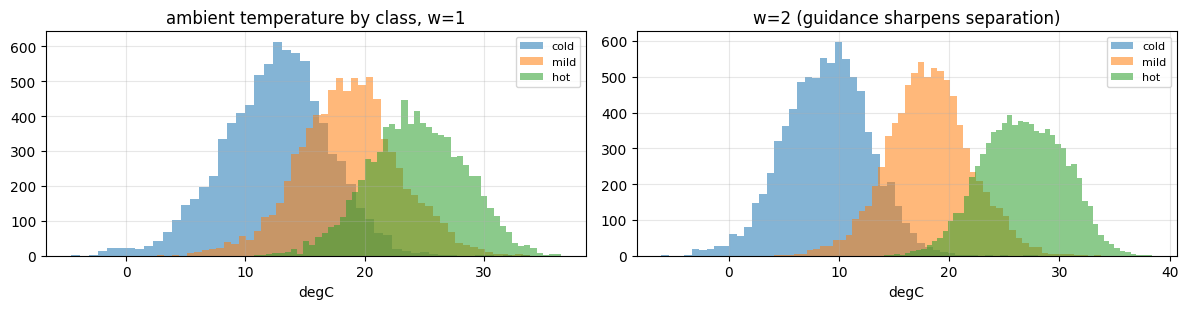

In [15]:
#@title does the conditioning actually control anything?
print("mean ambient temperature of generated weeks, by requested class (degC)\n")
rows = {}
for w in [1.0, 2.0]:
    rows[f"generated w={w}"] = {CLASS_NAMES[c]: to_physical(bank[w][c])[:, :, AT].mean() for c in range(N_CLASSES)}
rows["real (training)"] = {CLASS_NAMES[c]: at_c(c, x_train, y_train) for c in range(N_CLASSES)}
ctrl = pd.DataFrame(rows).T
ctrl["hot - cold"] = ctrl["hot"] - ctrl["cold"]
print(ctrl.round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
for c in range(N_CLASSES):
    ax[0].hist(to_physical(bank[1.0][c])[:, :, AT].ravel(), bins=50, alpha=0.55, label=CLASS_NAMES[c])
    ax[1].hist(to_physical(bank[2.0][c])[:, :, AT].ravel(), bins=50, alpha=0.55, label=CLASS_NAMES[c])
ax[0].set_title("ambient temperature by class, w=1"); ax[1].set_title("w=2 (guidance sharpens separation)")
for a in ax: a.set_xlabel("degC"); a.legend(fontsize=8); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Conditioning works, and guidance does exactly what the theory says it should.

At `w = 1` the model separates the classes but **understates** the real spread — 11.8 °C between the cold and hot classes against 15.2 °C in the training data. Turn guidance up to `w = 2` and it **overshoots** to 17.8 °C: the sampler is now exaggerating whatever distinguishes "hot" from the average week, pushing samples further from the class mean than any real week sits.

That overshoot is the guidance trade-off made visible. Higher `w` gives you crisper, more obviously on-class samples and less diversity, and past some point it generates weeks the plant has never had. For picture generation that reads as "more stylised". For process data it reads as "physically less plausible" — so if you are generating operating cases to test against, prefer a low guidance scale and check the scorecard, rather than turning `w` up until the classes look neatly separated.

## Doing the job: filling the holes in the historian

Everything so far has been about whether the model is any good. This section uses it.

Recall the second diagnostic cell: **13–18% of every year's hours are missing from this dataset.** That is not a quirk of a teaching set — it is what a historian pull looks like after comms dropouts, analyser maintenance, and instrument calibrations. Downstream, those holes break the emissions surrogate, the mass balance, and the monthly report.

A diffusion model trained on normal operation can fill them, and it needs no retraining to do it. The trick is the same one Day 3 used for a failed transmitter: at every reverse step, overwrite the **observed** hours with the real data noised to that step's level, and let the model generate only into the holes. The observed data stays pinned to measurement; the gap is filled with something consistent with it.

Two scenarios, because they have very different answers and very different baselines:

- **A — comms dropout.** Six consecutive hours where *every* tag is missing. You have good data either side.
- **B — analyser down.** The NOx analyser is out for the whole week. Ten other tags are healthy the entire time; nothing to interpolate between.

We score mean absolute error against the withheld truth, in engineering units, on **held-out 2014–15 weeks the model never saw**, and compare against what you would otherwise do: linear interpolation, hold-last-value, and a cross-channel least-squares fit.

In [16]:
#@title inpainting sampler (RePaint-style, conditioned)
@torch.no_grad()
def inpaint(known, mask, cls, guidance=1.0, resample=2, clip=5.0, seed=0):
    """known: (N,C,L) standardised. mask: 1 = observed, 0 = to be filled."""
    n = len(known)
    g = torch.Generator().manual_seed(seed)
    x = torch.randn(n, CHANNELS, WINDOW, generator=g).to(device)
    y    = cls.to(device)
    null = torch.full((n,), N_CLASSES, device=device, dtype=torch.long)
    for i in reversed(range(T_STEPS)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        for r in range(resample):
            e = torch.randn(known.shape, generator=g).to(device)
            x = mask * (sqrt_abar[i] * known + sqrt_1mab[i] * e) + (1 - mask) * x   # pin observed hours
            eps = ema(x, t, y)
            if guidance != 1.0:
                eps_u = ema(x, t, null); eps = eps_u + guidance * (eps - eps_u)
            x0   = ((x - sqrt_1mab[i] * eps) / sqrt_abar[i]).clamp(-clip, clip)
            mean = coef_x0[i] * x0 + coef_xt[i] * x
            x = mean + post_var[i].sqrt() * torch.randn(x.shape, generator=g).to(device) if i > 0 else mean
            if r < resample - 1 and i > 0:                                          # RePaint jump-back
                z = torch.randn(x.shape, generator=g).to(device)
                x = (1 - betas[i]).sqrt() * x + betas[i].sqrt() * z
    return mask * known + (1 - mask) * x

N_FILL = 32
sel    = np.random.RandomState(0).choice(len(x_test), N_FILL, replace=False)
truth  = torch.tensor(x_test[sel]).permute(0, 2, 1).to(device)
truth_cls = torch.tensor(y_test[sel])
print(f"filling gaps in {N_FILL} held-out weeks from 2014-15")

filling gaps in 32 held-out weeks from 2014-15


In [17]:
#@title scenario A - a six-hour comms dropout on every tag
G0, G1 = 80, 86                                    # six consecutive hours, mid-week
mask = torch.ones_like(truth); mask[:, :, G0:G1] = 0
filled = inpaint(truth, mask, truth_cls, seed=1)

hole = (mask == 0)
lin  = truth.clone()
ramp = torch.linspace(0, 1, G1 - G0 + 2, device=device)[1:-1]
a, b = truth[:, :, G0-1], truth[:, :, G1]
lin[:, :, G0:G1] = a[:, :, None] + (b - a)[:, :, None] * ramp[None, None, :]
hold = truth.clone(); hold[:, :, G0:G1] = truth[:, :, G0-1][:, :, None]

sd_t = torch.tensor(sd, device=device, dtype=torch.float32)[None, :, None]
def mae_eng(pred):
    """mean absolute error over the missing hours, per tag, in engineering units"""
    d = (pred - truth).abs() * sd_t
    return np.array([d[:, ch, G0:G1].mean().item() for ch in range(CHANNELS)])

tabA = pd.DataFrame({"diffusion": mae_eng(filled), "linear": mae_eng(lin), "hold-last": mae_eng(hold)}, index=TAGS)
tabA.loc["MEAN (sigma units)"] = [((p - truth).abs()[hole]).mean().item() for p in (filled, lin, hold)]
print("MAE over the 6 missing hours - engineering units per tag, last row in sigma\n")
print(tabA.round(3).to_string())

MAE over the 6 missing hours - engineering units per tag, last row in sigma

                    diffusion  linear  hold-last
AT                      1.540   1.103      2.109
AP                      0.524   0.294      0.990
AH                      6.931   5.057      9.905
AFDP                    0.302   0.243      0.322
GTEP                    2.294   1.828      2.418
TIT                    10.466   7.496      9.613
TAT                     2.708   2.082      2.555
TEY                     8.329   6.549      8.343
CDP                     0.560   0.464      0.599
CO                      1.272   1.133      1.098
NOX                     5.303   3.117      4.041
MEAN (sigma units)      0.430   0.328      0.448


In [18]:
#@title scenario B - the NOx analyser is down all week
k = TAGS.index("NOX")
maskB = torch.ones_like(truth); maskB[:, k, :] = 0
filledB = inpaint(truth, maskB, truth_cls, seed=2)
holeB = (maskB == 0)

# baselines you would actually reach for
zeros = torch.zeros_like(truth)                                        # predict the training mean
others = [j for j in range(CHANNELS) if j != k]
A = np.c_[x_train.reshape(-1, CHANNELS)[:, others], np.ones(len(x_train)*WINDOW)]
coef = np.linalg.lstsq(A, x_train.reshape(-1, CHANNELS)[:, k], rcond=None)[0]
G = truth.cpu().numpy()
ols_np = (np.einsum("bcl,c->bl", G[:, others, :], coef[:-1]) + coef[-1]).astype(np.float32)
ols = torch.from_numpy(ols_np).to(device)   # float32: MPS rejects float64
ols_full = truth.clone(); ols_full[:, k, :] = ols

rows = {}
for name, pred in [("diffusion", filledB), ("train mean", zeros), ("cross-channel OLS", ols_full)]:
    err = (pred[:, k, :] - truth[:, k, :]).abs()
    rows[name] = {"MAE (mg/m3)": (err * sd[k]).mean().item(), "MAE (sigma)": err.mean().item()}
print("reconstructing a week of NOx from the ten healthy tags\n")
print(pd.DataFrame(rows).T.round(3).to_string())
print(f"\nfor scale: real NOx in these weeks spans {(truth[:,k,:].min()*sd[k]+mu[k]):.1f} to {(truth[:,k,:].max()*sd[k]+mu[k]):.1f} mg/m3")

reconstructing a week of NOx from the ten healthy tags

                   MAE (mg/m3)  MAE (sigma)
diffusion               10.332        0.936
train mean              12.569        1.139
cross-channel OLS        9.279        0.841



for scale: real NOx in these weeks spans 35.7 to 119.7 mg/m3


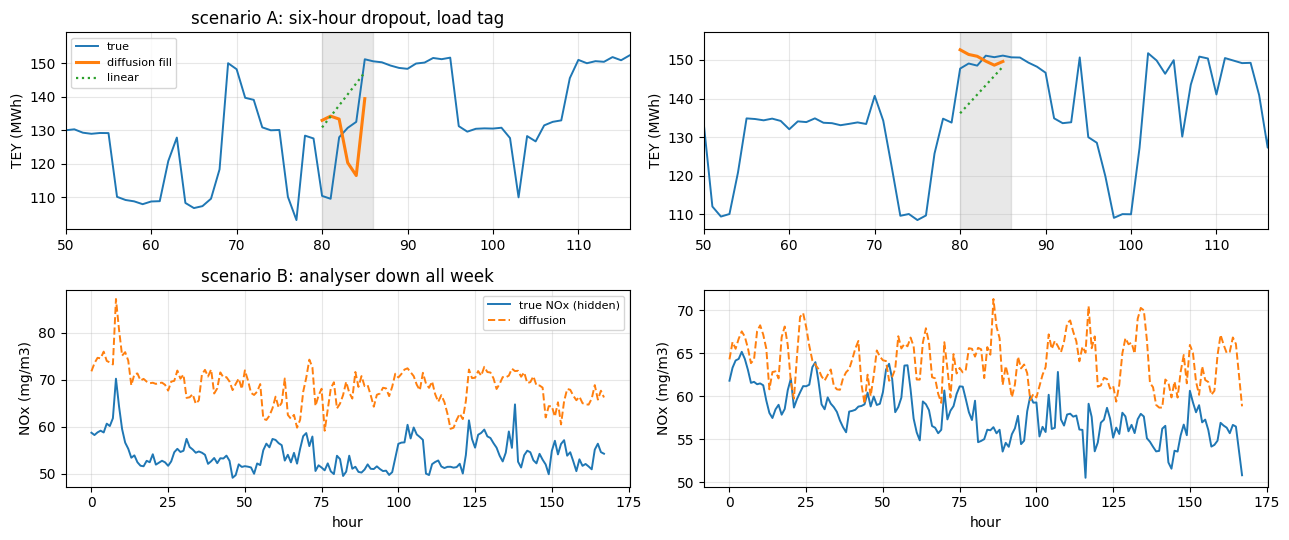

In [19]:
#@title what the filled historian looks like
fig, axes = plt.subplots(2, 2, figsize=(13, 5.5))
for j, ax in enumerate(axes[0]):
    kk = TAGS.index("TEY")
    ax.plot(np.arange(WINDOW), truth[j, kk].cpu()*sd[kk]+mu[kk], lw=1.4, label="true")
    ax.plot(np.arange(G0, G1), filled[j, kk, G0:G1].cpu()*sd[kk]+mu[kk], lw=2.2, label="diffusion fill")
    ax.plot(np.arange(G0, G1), lin[j, kk, G0:G1].cpu()*sd[kk]+mu[kk], lw=1.6, ls=":", label="linear")
    ax.axvspan(G0, G1, color="grey", alpha=0.18); ax.set_xlim(G0-30, G1+30)
    ax.set_ylabel("TEY (MWh)"); ax.grid(alpha=0.3)
axes[0,0].legend(fontsize=8); axes[0,0].set_title("scenario A: six-hour dropout, load tag")
for j, ax in enumerate(axes[1]):
    ax.plot(truth[j, k].cpu()*sd[k]+mu[k], lw=1.4, label="true NOx (hidden)")
    ax.plot(filledB[j, k].cpu()*sd[k]+mu[k], lw=1.4, ls="--", label="diffusion")
    ax.set_ylabel("NOx (mg/m3)"); ax.set_xlabel("hour"); ax.grid(alpha=0.3)
axes[1,0].legend(fontsize=8); axes[1,0].set_title("scenario B: analyser down all week")
plt.tight_layout(); plt.show()

**Both scenarios go to the classical baselines, and that is the finding.**

For the **six-hour comms dropout**, linear interpolation wins on every single tag — 0.328σ against the diffusion model's 0.430σ. Six hours is short relative to how fast these signals move, so a straight line between the last good reading and the first good one is very nearly optimal. The diffusion model is doing something much harder than the problem requires, and paying for it.

For the **dead NOx analyser**, the honest result is more interesting: the diffusion model beats predicting the training mean (10.33 against 12.57 mg/m³) but **loses to an ordinary cross-channel least-squares fit at 9.28 mg/m³**. On a gas turbine, NOx is close to a linear function of firing temperature and load, and when the true relationship is that simple a linear model estimated from 22,000 hours is very hard to beat. A generative model has to spend its capacity learning the whole joint distribution; OLS only has to learn one conditional mean, which is all this task asks for.

So the recommendation for *this* unit is: **interpolate short gaps, regress dead analysers, and do not reach for the diffusion model for either.**

That is worth more to you than a win would have been. The same experiment on the Day 3 pump rig came out the other way — there the diffusion model beat a cross-channel fit, because the relationships between vibration, flow and current are genuinely nonlinear and state-dependent. The method is not what decides it; the physics of your particular unit is. The only way to know which case you are in is to run the comparison, which is what this section is.

Two caveats before you generalise from these numbers. The fill is a *sample*, not an estimate — run it twice with different seeds and you get two plausible weeks; for an uncertainty band, generate 20 and take the median and spread, which is something OLS cannot give you at all. And the model reconstructs **pre-2014 NOx behaviour**, because that is the plant it was trained on; filling 2015 NOx with it inherits the 0.8σ offset we found earlier. A filled historian that is silently biased is worse than an empty one.

## Where this leaves you

**What you did with it.** You filled real holes in a real historian — a six-hour comms dropout across every tag, and a NOx analyser out for a week — scored against withheld truth on years the model never saw, and benchmarked against interpolation and a cross-channel fit. The answer came back **use the classical methods** (0.328σ for linear interpolation, 9.28 mg/m³ for OLS, both ahead of diffusion). That verdict, with numbers behind it, is the deliverable. The sampler was the means of finding out.

**What the model does.** One conditional DDPM, trained on three years of hourly data from a single turbine, generates weeks of operation on demand for a requested ambient condition — reproducing the tight load/pressure coupling, the negative CO–firing-temperature relationship, the temperature limiter, and the exhaust setpoint that the real controller enforces.

**The lesson to carry out of the room.** The Gaussian baseline matches every correlation in the data and is still physically impossible. Second-moment agreement is not process knowledge. Whenever someone shows you synthetic process data, ask what *physical* constraint they checked — not what correlation they matched.

**Honest limitations.**

- **The model still emits physically impossible values** — 1.6% negative CO, 5.8% of hours above the inlet-temperature limiter. Ten times better than the Gaussian, but not zero, and nothing in the architecture forbids it. Bounded channels want a log transform or an explicit clamp.

- The independent-sample count is ~132 training weeks, whatever the window count says. This is a small-data problem.
- Windows are index-contiguous, not time-contiguous: 13–18% of calendar hours are missing and unlocatable without timestamps.
- The model generates **pre-2014 NOx**, because that is the plant it was trained on. Using it to predict post-retrofit emissions would be wrong, and the 0.8σ break is visible in the data if you look.
- Guidance above `w ≈ 2` sharpens class separation but narrows diversity — the usual trade, and worth sweeping.
- Conditioning is a coarse 3-way ambient bucket. Continuous conditioning on `AT` and `TEY` jointly is the natural next step.

**Worth trying next.** Condition on load as well as weather and generate a hot-week-at-full-load case the plant has never actually run — then read the CO and NOx distribution against your permit limit to size the headroom. Swap the tercile label for continuous conditioning on `AT` and `TEY` jointly. Or turn the gap-filler into an uncertainty band: fill the same hole 20 times and report the median and spread rather than one sample.

**References.** Ho, Jain & Abbeel, *Denoising Diffusion Probabilistic Models* (2020), [arXiv:2006.11239](https://arxiv.org/abs/2006.11239) · Ho & Salimans, *Classifier-Free Diffusion Guidance* (2022), [arXiv:2207.12598](https://arxiv.org/abs/2207.12598) · Nichol & Dhariwal, *Improved DDPM* (2021), [arXiv:2102.09672](https://arxiv.org/abs/2102.09672) · Kaya, Tüfekci & Uzun, *Predicting CO and NOx emissions from gas turbines* (2019); dataset at [UCI](https://archive.ics.uci.edu/dataset/551/gas+turbine+co+and+nox+emission+data+set), CC BY 4.0